In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('master_dataset.csv').copy()
df.head()

,PLANNING_AREA,total_footfall,total_inflow,weekday_volume,weekend_volume,afternoon,evening,lunch,morning,other,...,working_age_pct,pct_high_income,competitor_per_1k,inflow_ratio,lunch_share,evening_share,weekend_share,sfa_active_count,sfa_per_1k,market_quadrant
0,ANG MO KIO,12643933,-55151,9188236,3455697,912723,3075086,2625614,2266392,3764118,...,41.2,38.3,0.99,-0.0044,20.8,24.3,27.3,1075,6.62,Competitive
1,BEDOK,17435585,100131,12241821,5193764,1406209,4168207,3620726,2940278,5300165,...,41.7,46.5,1.48,0.0057,20.8,23.9,29.8,1597,5.76,Saturated
2,BISHAN,6582346,-200892,4724065,1858281,500037,1606145,1437977,1182105,1856082,...,41.8,58.7,2.12,-0.0305,21.8,24.4,28.2,625,7.16,Saturated
3,BOON LAY,342658,34532,255329,87329,23326,93916,34464,91175,99777,...,NaN,NaN,NaN,0.1008,10.1,27.4,25.5,135,NaN,Opportunity
4,BUKIT BATOK,9742955,-40587,6957018,2785937,754172,2407520,1975790,1648436,2957037,...,45.1,43.4,1.08,-0.0042,20.3,24.7,28.6,820,5.19,Saturated


In [3]:
df.columns

Index(['PLANNING_AREA', 'total_footfall', 'total_inflow', 'weekday_volume',
       'weekend_volume', 'afternoon', 'evening', 'lunch', 'morning', 'other',
       'low_income', 'mid_income', 'high_income', 'children', 'teens_youth',
       'young_adults', 'mid_age_adults', 'older_adults', 'seniors',
       'rent_proxy_psm', 'competitor_count', 'unique_competitor_names',
       'unique_category_count', 'mean_rating', 'median_rating',
       'total_reviews', 'median_reviews', 'mean_price_mid',
       'rated_place_count', 'priced_place_count', 'hawker_stall_count',
       'restaurant_count', 'chinese_count', 'japanese_count', 'indian_count',
       'cafe_count', 'thai_count', 'fast_food_count', 'rating_coverage_ratio',
       'price_coverage_ratio', 'income_missing', 'demo_missing',
       'rent_missing', 'population_total', 'working_age_pct',
       'pct_high_income', 'competitor_per_1k', 'inflow_ratio', 'lunch_share',
       'evening_share', 'weekend_share', 'sfa_active_count', 'sfa_per_1

In [4]:
percent_missing = df.isnull().mean() * 100
print(percent_missing)

PLANNING_AREA               0.0
total_footfall              0.0
total_inflow                0.0
weekday_volume              0.0
weekend_volume              0.0
afternoon                   0.0
evening                     0.0
lunch                       0.0
morning                     0.0
other                       0.0
low_income                 40.0
mid_income                 40.0
high_income                40.0
children                   16.0
teens_youth                16.0
young_adults               16.0
mid_age_adults             16.0
older_adults               16.0
seniors                    16.0
rent_proxy_psm             24.0
competitor_count            0.0
unique_competitor_names     0.0
unique_category_count       0.0
mean_rating                 0.0
median_rating               0.0
total_reviews               0.0
median_reviews              0.0
mean_price_mid              2.0
rated_place_count           0.0
priced_place_count          0.0
hawker_stall_count          0.0
restaura

# Clustering

In [5]:
analysis_df = df.copy()

# ----------------------------
# Demand features
# ----------------------------
analysis_df["log_footfall"] = np.log1p(analysis_df["total_footfall"])

analysis_df["weekday_ratio"] = (
    analysis_df["weekday_volume"] /
    (analysis_df["weekday_volume"] + analysis_df["weekend_volume"])
)

analysis_df["weekend_ratio"] = (
    analysis_df["weekend_volume"] /
    (analysis_df["weekday_volume"] + analysis_df["weekend_volume"])
)

time_cols = ["morning", "lunch", "evening", "afternoon", "other"]
analysis_df[[f"{col}_ratio" for col in time_cols]] = (
    analysis_df[time_cols].div(analysis_df[time_cols].sum(axis=1), axis=0)
)

# ----------------------------
# Income features
# ----------------------------
income_cols = ["low_income", "mid_income", "high_income"]
analysis_df["income_total"] = analysis_df[income_cols].sum(axis=1, min_count=1)
for col in income_cols:
    analysis_df[f"{col}_ratio"] = analysis_df[col] / analysis_df["income_total"]

# ----------------------------
# Demographic features
# ----------------------------
demo_cols = [
    "children", "teens_youth", "young_adults",
    "mid_age_adults", "older_adults", "seniors"
]
analysis_df["demo_total"] = analysis_df[demo_cols].sum(axis=1, min_count=1)
for col in demo_cols:
    analysis_df[f"{col}_ratio"] = analysis_df[col] / analysis_df["demo_total"]

# ----------------------------
# Competition features
# ----------------------------
analysis_df["log_competitor_count"] = np.log1p(analysis_df["competitor_count"])
analysis_df["log_sfa_count"]        = np.log1p(analysis_df["sfa_active_count"])

competition_count_cols = [
    "hawker_stall_count", "restaurant_count", "chinese_count",
    "japanese_count", "indian_count", "cafe_count", "thai_count", "fast_food_count",
]
for col in competition_count_cols:
    analysis_df[f"{col}_ratio"] = analysis_df[col] / analysis_df["competitor_count"]

# ----------------------------
# Market quadrant encoding
# ----------------------------
quadrant_order = {'Opportunity': 0, 'Competitive': 1, 'Niche': 2, 'Saturated': 3}
analysis_df["market_quadrant_code"] = analysis_df["market_quadrant"].map(quadrant_order)

# ----------------------------
# Select analysis columns
# ----------------------------
analysis_cols = [
    "PLANNING_AREA",
    # Demand
    "log_footfall", "inflow_ratio", "weekday_ratio",
    "morning_ratio", "lunch_ratio", "afternoon_ratio", "evening_ratio",
    # Income & demographics
    "mid_income_ratio", "high_income_ratio", "working_age_pct",
    "children_ratio", "teens_youth_ratio", "young_adults_ratio",
    "mid_age_adults_ratio", "seniors_ratio",
    # Competition (Google Places + SFA)
    "log_competitor_count", "log_sfa_count",
    "unique_category_count", "mean_rating", "mean_price_mid",
    "hawker_stall_count_ratio", "restaurant_count_ratio",
    "cafe_count_ratio", "fast_food_count_ratio",
]

clustering_df = analysis_df[analysis_cols].copy()

In [6]:
clustering_df.head()

,PLANNING_AREA,log_footfall,inflow_ratio,weekday_ratio,morning_ratio,lunch_ratio,afternoon_ratio,evening_ratio,mid_income_ratio,high_income_ratio,...,seniors_ratio,log_competitor_count,log_sfa_count,unique_category_count,mean_rating,mean_price_mid,hawker_stall_count_ratio,restaurant_count_ratio,cafe_count_ratio,fast_food_count_ratio
0,ANG MO KIO,16.352688,-0.004362,0.726691,0.179247,0.207658,0.072187,0.243206,0.343006,0.382544,...,0.216944,5.087596,6.981006,43,4.196273,12.378676,0.273292,0.130435,0.031056,0.049689
1,BEDOK,16.674024,0.005743,0.702117,0.168637,0.207663,0.080652,0.239063,0.308862,0.465127,...,0.192609,6.016157,7.376508,77,4.223136,13.389706,0.161369,0.207824,0.026895,0.019560
2,BISHAN,15.699902,-0.030520,0.717687,0.179587,0.218460,0.075966,0.244008,0.266858,0.587208,...,0.183713,5.225747,6.439350,46,3.999435,13.626761,0.162162,0.216216,0.048649,0.032432
3,BOON LAY,12.744491,0.100777,0.745142,0.266082,0.100578,0.068074,0.274081,NaN,NaN,...,NaN,2.197225,4.912655,6,4.012500,5.500000,0.125000,0.375000,0.000000,0.000000
4,BUKIT BATOK,16.092055,-0.004166,0.714056,0.169193,0.202792,0.077407,0.247104,0.352313,0.433633,...,0.137111,5.147494,6.710523,39,3.951205,10.701550,0.210526,0.204678,0.011696,0.046784


In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# ----------------------------
# 1. keep area names aside
# ----------------------------
area_names = clustering_df["PLANNING_AREA"].copy()
X = clustering_df.drop(columns=["PLANNING_AREA"]).copy()

# ----------------------------
# 2. inspect missingness
# ----------------------------
missing_summary = X.isna().sum().sort_values(ascending=False)
print("Missing values by column:")
print(missing_summary[missing_summary > 0])

# ----------------------------
# 3. impute missing values
# median is a good first choice
# ----------------------------
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# ----------------------------
# 4. scale features
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# optional: keep as dataframe for inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Scaled shape:", X_scaled_df.shape)
X_scaled_df.head()

Missing values by column:
mid_income_ratio        20
high_income_ratio       20
mid_age_adults_ratio     8
seniors_ratio            8
teens_youth_ratio        8
children_ratio           8
working_age_pct          8
young_adults_ratio       8
mean_price_mid           1
dtype: int64
Scaled shape: (50, 24)


,log_footfall,inflow_ratio,weekday_ratio,morning_ratio,lunch_ratio,afternoon_ratio,evening_ratio,mid_income_ratio,high_income_ratio,working_age_pct,...,seniors_ratio,log_competitor_count,log_sfa_count,unique_category_count,mean_rating,mean_price_mid,hawker_stall_count_ratio,restaurant_count_ratio,cafe_count_ratio,fast_food_count_ratio
0,0.822056,-0.124978,0.681202,0.533756,-0.025325,-0.683141,-0.099677,0.557453,-1.067672,-0.815872,...,1.369395,0.469963,0.703771,0.117443,0.032008,-0.425901,0.945029,-0.602705,0.615522,1.286915
1,1.011766,-0.048596,0.247655,0.254379,-0.025200,-0.327365,-0.227500,-0.022176,-0.221118,-0.701796,...,0.863609,1.061811,0.948864,1.342311,0.152993,-0.363130,0.098096,-0.042178,0.381996,0.017007
2,0.436663,-0.322706,0.522348,0.542703,0.243984,-0.524283,-0.074949,-0.735243,1.030345,-0.678981,...,0.678718,0.558018,0.368106,0.225520,-0.854505,-0.348412,0.104097,0.018606,1.602862,0.559562
3,-1.308155,0.669766,1.006721,2.820068,-2.695062,-0.856003,0.852829,0.127844,-0.237597,-0.154231,...,-0.077819,-1.372305,-0.577989,-1.215501,-0.795663,-0.852975,-0.177114,1.168672,-1.127398,-0.807410
4,0.668183,-0.123496,0.458291,0.269018,-0.146654,-0.463739,0.020556,0.715450,-0.543955,0.073921,...,-0.289875,0.508141,0.536152,-0.026659,-1.071722,-0.530028,0.470074,-0.064962,-0.471000,1.164440


In [9]:
kmeans_results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    kmeans_results.append({"k": k, "silhouette": sil, "inertia": kmeans.inertia_})

kmeans_results_df = pd.DataFrame(kmeans_results)
kmeans_results_df

,k,silhouette,inertia
0,2,0.237251,981.478567
1,3,0.239619,845.616208
2,4,0.230483,731.585660
3,5,0.250157,640.819968
4,6,0.168012,556.535191
5,7,0.159481,508.617179
6,8,0.159946,462.084801
7,9,0.172504,415.460355
8,10,0.170299,400.626924


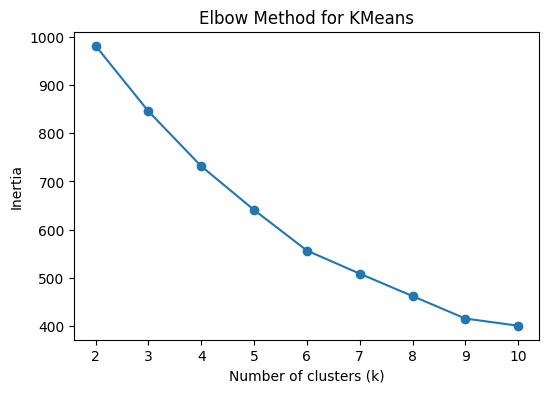

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(kmeans_results_df["k"], kmeans_results_df["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.xticks(kmeans_results_df["k"])
plt.show()

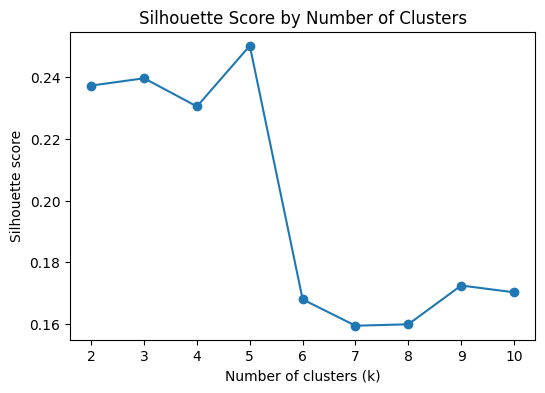

In [13]:
plt.figure(figsize=(6,4))
plt.plot(kmeans_results_df["k"], kmeans_results_df["silhouette"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(kmeans_results_df["k"])
plt.show()

In [14]:
compare_results = {}

for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)

    out = X_imputed.copy()
    out.insert(0, "PLANNING_AREA", area_names)
    out["cluster"] = labels

    cluster_sizes = out["cluster"].value_counts().sort_index()
    cluster_summary = out.groupby("cluster").mean(numeric_only=True)

    compare_results[k] = {
        "labels": labels,
        "sizes": cluster_sizes,
        "summary": cluster_summary,
        "silhouette": silhouette_score(X_scaled, labels),
        "inertia": km.inertia_,
    }

    print(f"\n=== k = {k} ===")
    print("Silhouette:", compare_results[k]["silhouette"])
    print("Inertia:", compare_results[k]["inertia"])
    print("\nCluster sizes:")
    print(cluster_sizes)


=== k = 2 ===
Silhouette: 0.23725119504671763
Inertia: 981.4785669803346

Cluster sizes:
cluster
0    33
1    17
Name: count, dtype: int64

=== k = 3 ===
Silhouette: 0.23961938423725218
Inertia: 845.6162082506091

Cluster sizes:
cluster
0     9
1    35
2     6
Name: count, dtype: int64

=== k = 4 ===
Silhouette: 0.23048347107883063
Inertia: 731.585659591608

Cluster sizes:
cluster
0     8
1    10
2     4
3    28
Name: count, dtype: int64


In [15]:
feature_cols = X_imputed.columns.tolist()
overall_mean = X_imputed[feature_cols].mean(numeric_only=True)

for k in [2, 3, 4]:
    print(f"\n\n===== k = {k} : cluster summary (difference from overall mean) =====")
    cluster_summary = compare_results[k]["summary"]
    cluster_diff = cluster_summary - overall_mean
    display(cluster_diff.round(3))



===== k = 2 : cluster summary (difference from overall mean) =====


,log_footfall,inflow_ratio,weekday_ratio,morning_ratio,lunch_ratio,afternoon_ratio,evening_ratio,mid_income_ratio,high_income_ratio,working_age_pct,...,seniors_ratio,log_competitor_count,log_sfa_count,unique_category_count,mean_rating,mean_price_mid,hawker_stall_count_ratio,restaurant_count_ratio,cafe_count_ratio,fast_food_count_ratio
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.992,-0.011,0.016,0.003,0.003,-0.004,0.004,0.007,-0.008,0.372,...,0.009,0.951,0.898,15.018,-0.026,-3.144,0.031,-0.047,0.008,0.009
1,-1.925,0.022,-0.032,-0.007,-0.006,0.008,-0.008,-0.014,0.016,-0.723,...,-0.018,-1.846,-1.743,-29.152,0.050,6.103,-0.060,0.091,-0.015,-0.017




===== k = 3 : cluster summary (difference from overall mean) =====


,log_footfall,inflow_ratio,weekday_ratio,morning_ratio,lunch_ratio,afternoon_ratio,evening_ratio,mid_income_ratio,high_income_ratio,working_age_pct,...,seniors_ratio,log_competitor_count,log_sfa_count,unique_category_count,mean_rating,mean_price_mid,hawker_stall_count_ratio,restaurant_count_ratio,cafe_count_ratio,fast_food_count_ratio
cluster,,,,,,,,,,,,,,,,,,,,,
0,-1.561,-0.016,0.027,0.035,-0.057,-0.014,0.026,0.008,-0.023,-1.198,...,-0.016,-1.998,-1.571,-32.518,-0.094,-9.784,-0.031,0.106,-0.020,-0.006
1,0.947,-0.012,0.013,0.001,0.006,-0.004,0.001,0.002,0.001,0.447,...,0.007,0.903,0.813,13.889,-0.011,-1.620,0.031,-0.039,0.008,0.005
2,-3.182,0.095,-0.117,-0.058,0.051,0.043,-0.047,-0.022,0.029,-0.809,...,-0.017,-2.268,-2.387,-32.240,0.207,24.123,-0.133,0.070,-0.014,-0.019




===== k = 4 : cluster summary (difference from overall mean) =====


,log_footfall,inflow_ratio,weekday_ratio,morning_ratio,lunch_ratio,afternoon_ratio,evening_ratio,mid_income_ratio,high_income_ratio,working_age_pct,...,seniors_ratio,log_competitor_count,log_sfa_count,unique_category_count,mean_rating,mean_price_mid,hawker_stall_count_ratio,restaurant_count_ratio,cafe_count_ratio,fast_food_count_ratio
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.026,-0.011,-0.008,-0.017,0.021,0.008,0.002,-0.049,0.095,6.661,...,-0.035,0.482,0.237,12.635,0.146,13.275,-0.098,0.027,0.014,-0.008
1,-1.624,-0.021,0.017,0.026,-0.050,-0.010,0.021,0.008,-0.023,-1.146,...,-0.015,-2.073,-1.622,-32.940,-0.073,-8.729,-0.043,0.124,-0.020,-0.008
2,-3.661,0.151,-0.154,-0.074,0.062,0.058,-0.061,0.008,-0.023,-2.226,...,-0.019,-2.463,-2.645,-34.490,0.215,28.664,-0.135,0.022,-0.020,-0.019
3,1.111,-0.011,0.018,0.006,0.003,-0.007,0.001,0.010,-0.016,-1.176,...,0.018,0.954,0.890,13.081,-0.046,-4.770,0.063,-0.055,0.006,0.008


In [16]:
for k in [2, 3, 4]:
    print(f"\n\n===== k = {k} : top distinguishing features =====")
    cluster_diff = compare_results[k]["summary"] - overall_mean

    for cl in cluster_diff.index:
        s = cluster_diff.loc[cl].sort_values(ascending=False)
        top_high = s.head(5)
        top_low = s.tail(5)

        print(f"\nCluster {cl}")
        print("Highest vs overall:")
        print(top_high.round(3))
        print("\nLowest vs overall:")
        print(top_low.round(3))



===== k = 2 : top distinguishing features =====

Cluster 0
Highest vs overall:
unique_category_count    15.018
log_footfall              0.992
log_competitor_count      0.951
log_sfa_count             0.898
working_age_pct           0.372
Name: 0, dtype: float64

Lowest vs overall:
high_income_ratio        -0.008
inflow_ratio             -0.011
mean_rating              -0.026
restaurant_count_ratio   -0.047
mean_price_mid           -3.144
Name: 0, dtype: float64

Cluster 1
Highest vs overall:
mean_price_mid            6.103
restaurant_count_ratio    0.091
mean_rating               0.050
inflow_ratio              0.022
high_income_ratio         0.016
Name: 1, dtype: float64

Lowest vs overall:
working_age_pct          -0.723
log_sfa_count            -1.743
log_competitor_count     -1.846
log_footfall             -1.925
unique_category_count   -29.152
Name: 1, dtype: float64


===== k = 3 : top distinguishing features =====

Cluster 0
Highest vs overall:
restaurant_count_ratio    0.106

In [17]:
for k in [2, 3, 4]:
    print(f"\n\n===== k = {k} : planning areas by cluster =====")
    labels = compare_results[k]["labels"]
    out = clustering_df[["PLANNING_AREA"]].copy()
    out["cluster"] = labels

    for cl in sorted(out["cluster"].unique()):
        print(f"\nCluster {cl}:")
        print(out.loc[out["cluster"] == cl, "PLANNING_AREA"].sort_values().tolist())



===== k = 2 : planning areas by cluster =====

Cluster 0:
['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CHOA CHU KANG', 'CLEMENTI', 'DOWNTOWN CORE', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG', 'MARINE PARADE', 'MUSEUM', 'NOVENA', 'ORCHARD', 'OUTRAM', 'PASIR RIS', 'PIONEER', 'PUNGGOL', 'QUEENSTOWN', 'ROCHOR', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'SINGAPORE RIVER', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']

Cluster 1:
['BOON LAY', 'CENTRAL WATER CATCHMENT', 'CHANGI', 'LIM CHU KANG', 'MANDAI', 'MARINA SOUTH', 'NEWTON', 'PAYA LEBAR', 'RIVER VALLEY', 'SELETAR', 'SOUTHERN ISLANDS', 'STRAITS VIEW', 'SUNGEI KADUT', 'TANGLIN', 'TENGAH', 'TUAS', 'WESTERN WATER CATCHMENT']


===== k = 3 : planning areas by cluster =====

Cluster 0:
['BOON LAY', 'MANDAI', 'PAYA LEBAR', 'PIONEER', 'SELETAR', 'SUNGEI KADUT', 'TENGAH', 'TUAS', 'WESTERN WATER CATCHMENT']

Cluster 1:
['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT ME

In [18]:
rows = []
for k in [2, 3, 4]:
    sizes = compare_results[k]["sizes"]
    rows.append({
        "k": k,
        "silhouette": compare_results[k]["silhouette"],
        "inertia": compare_results[k]["inertia"],
        "n_clusters": len(sizes),
        "smallest_cluster": sizes.min(),
        "largest_cluster": sizes.max(),
    })

comparison_df = pd.DataFrame(rows)
comparison_df

,k,silhouette,inertia,n_clusters,smallest_cluster,largest_cluster
0,2,0.237251,981.478567,2,17,33
1,3,0.239619,845.616208,3,6,35
2,4,0.230483,731.585660,4,4,28


k=4 seems to split the large mainstream/commercial space into two more meaningful types, without becoming too messy.

The four clusters appear to be:

Cluster 1
high log_footfall
high log_competitor_count
high unique_category_count
more hawker-heavy
lower mean_price_mid

This looks like:
high-traffic mainstream commercial / hawker-heavy hubs

Cluster 3
very high unique_category_count
high mean_price_mid
high mean_rating
higher high_income_ratio
lower hawker share

This looks like:
premium / lifestyle / more upscale commercial areas

Cluster 2
very high mean_price_mid
high mean_rating
high inflow_ratio
higher lunch orientation
but very low footfall, competitor count, and category count

This looks like:
small, niche, premium-oriented or sparse destination areas

Cluster 0
low footfall
low competitor count
low category diversity
low price
more restaurant-heavy
slightly higher morning/weekday/evening

This looks like:
lower-intensity local / neighborhood / less commercially dense areas

That is actually a pretty strong business segmentation.

With these memberships, k = 4 is interpretable, but it also reveals something important:
**two of the clusters are partly being driven by special-use / unusual planning areas.**

Likely exclude:

- CENTRAL WATER CATCHMENT
- WESTERN WATER CATCHMENT
- SOUTHERN ISLANDS
- LIM CHU KANG
- STRAITS VIEW
- maybe TUAS
- maybe MANDAI
- maybe SUNGEI KADUT depending on business framing

Then rerun KMeans.

Original rows: 50
After removing special-case areas: 45

Removed areas:
['CENTRAL WATER CATCHMENT', 'LIM CHU KANG', 'MARINA SOUTH', 'SOUTHERN ISLANDS', 'STRAITS VIEW']

Missing values by column before imputation:
mid_income_ratio        15
high_income_ratio       15
working_age_pct          5
children_ratio           5
teens_youth_ratio        5
young_adults_ratio       5
mid_age_adults_ratio     5
seniors_ratio            5
dtype: int64


,k,silhouette,inertia,smallest_cluster,largest_cluster
0,2,0.283999,879.367533,9,36
1,3,0.253597,712.701219,9,26
2,4,0.130012,652.429677,7,18
3,5,0.136302,599.424751,1,16
4,6,0.150824,542.797113,3,14


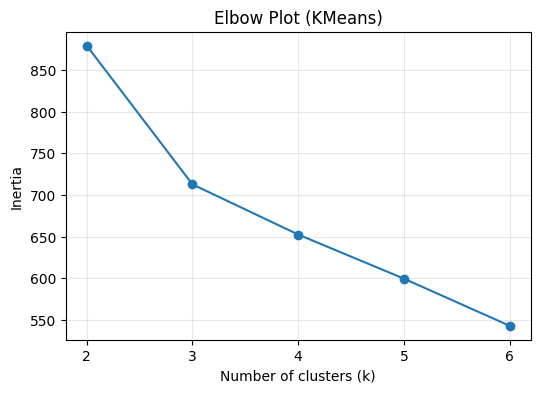

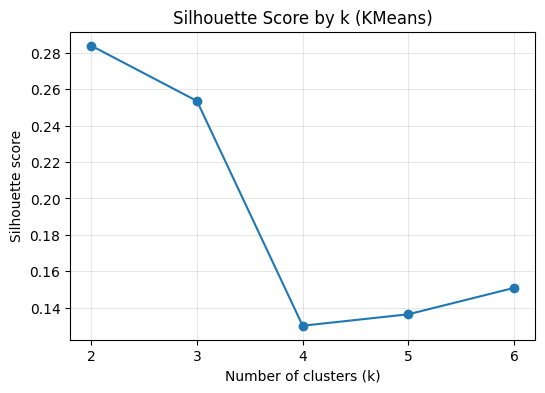

In [19]:
# =========================================================
# 1. Remove special-case / non-candidate areas
# =========================================================


special_case_areas = ['CENTRAL WATER CATCHMENT', 'LIM CHU KANG', 'MARINA SOUTH', 'SOUTHERN ISLANDS', 'STRAITS VIEW']

clustering_df_filtered = clustering_df[
    ~clustering_df["PLANNING_AREA"].isin(special_case_areas)
].copy()

print("Original rows:", len(clustering_df))
print("After removing special-case areas:", len(clustering_df_filtered))
print("\nRemoved areas:")
print(sorted(set(clustering_df["PLANNING_AREA"]) - set(clustering_df_filtered["PLANNING_AREA"])))

# =========================================================
# 2. Prepare X
# =========================================================
area_names = clustering_df_filtered["PLANNING_AREA"].copy()
X = clustering_df_filtered.drop(columns=["PLANNING_AREA"]).copy()

print("\nMissing values by column before imputation:")
print(X.isna().sum()[X.isna().sum() > 0])

# =========================================================
# 3. Impute missing values
# =========================================================
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# =========================================================
# 4. Scale features
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# =========================================================
# 5. KMeans: compare k
# =========================================================
kmeans_results = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)

    kmeans_results.append({
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "inertia": km.inertia_,
        "smallest_cluster": pd.Series(labels).value_counts().min(),
        "largest_cluster": pd.Series(labels).value_counts().max(),
    })

kmeans_results_df = pd.DataFrame(kmeans_results)
display(kmeans_results_df)

# =========================================================
# 6. Plot elbow + silhouette
# =========================================================
plt.figure(figsize=(6, 4))
plt.plot(kmeans_results_df["k"], kmeans_results_df["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot (KMeans)")
plt.xticks(kmeans_results_df["k"])
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(kmeans_results_df["k"], kmeans_results_df["silhouette"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score by k (KMeans)")
plt.xticks(kmeans_results_df["k"])
plt.grid(True, alpha=0.3)
plt.show()



In [20]:
# =========================================================
# 7. Choose final k for KMeans
# =========================================================
final_k = 3  # change if needed after inspection

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_output = X_imputed.copy()
kmeans_output["PLANNING_AREA"] = area_names.values
kmeans_output["cluster"] = kmeans_labels

print(f"\nKMeans cluster sizes (k={final_k}):")
print(kmeans_output["cluster"].value_counts().sort_index())

# cluster summary on imputed/original feature scale
kmeans_summary = kmeans_output.groupby("cluster").mean(numeric_only=True)

# difference from overall mean
overall_mean = X_imputed.mean(numeric_only=True)
kmeans_diff = kmeans_summary - overall_mean

print(f"\nTop distinguishing features for KMeans (k={final_k}):")
for cl in sorted(kmeans_diff.index):
    s = kmeans_diff.loc[cl].sort_values(ascending=False)
    print(f"\nCluster {cl}")
    print("Highest vs overall:")
    print(s.head(5).round(3))
    print("\nLowest vs overall:")
    print(s.tail(5).round(3))

print(f"\nPlanning areas by KMeans cluster (k={final_k}):")
for cl in sorted(kmeans_output["cluster"].unique()):
    areas = kmeans_output.loc[kmeans_output["cluster"] == cl, "PLANNING_AREA"].sort_values().tolist()
    print(f"\nCluster {cl}:")
    print(areas)

# =========================================================
# 8. Join cluster labels back to analysis_df for Pareto use
# =========================================================
cluster_label_map = dict(zip(area_names.values, kmeans_labels))
analysis_df["kmeans_cluster"] = analysis_df["PLANNING_AREA"].map(cluster_label_map)
print("\nCluster labels joined to analysis_df.")
display(
    analysis_df[["PLANNING_AREA", "kmeans_cluster"]]
    .dropna()
    .sort_values("kmeans_cluster")
    .reset_index(drop=True)
)



KMeans cluster sizes (k=3):
cluster
0    26
1     9
2    10
Name: count, dtype: int64

Top distinguishing features for KMeans (k=3):

Cluster 0
Highest vs overall:
unique_category_count       6.685
log_footfall                0.830
log_competitor_count        0.609
log_sfa_count               0.588
hawker_stall_count_ratio    0.060
Name: 0, dtype: float64

Lowest vs overall:
high_income_ratio        -0.019
restaurant_count_ratio   -0.050
mean_rating              -0.054
working_age_pct          -0.931
mean_price_mid           -3.449
Name: 0, dtype: float64

Cluster 1
Highest vs overall:
restaurant_count_ratio    0.115
morning_ratio             0.027
teens_youth_ratio         0.026
evening_ratio             0.020
weekday_ratio             0.012
Name: 1, dtype: float64

Lowest vs overall:
log_sfa_count            -1.852
log_footfall             -1.936
log_competitor_count     -2.278
mean_price_mid           -7.219
unique_category_count   -36.400
Name: 1, dtype: float64

Cluster 2
Highest

,PLANNING_AREA,kmeans_cluster
0,ANG MO KIO,0.0
1,BEDOK,0.0
2,BISHAN,0.0
3,BUKIT BATOK,0.0
4,BUKIT PANJANG,0.0
5,BUKIT MERAH,0.0
6,BUKIT TIMAH,0.0
7,CHOA CHU KANG,0.0
8,JURONG EAST,0.0
9,CLEMENTI,0.0


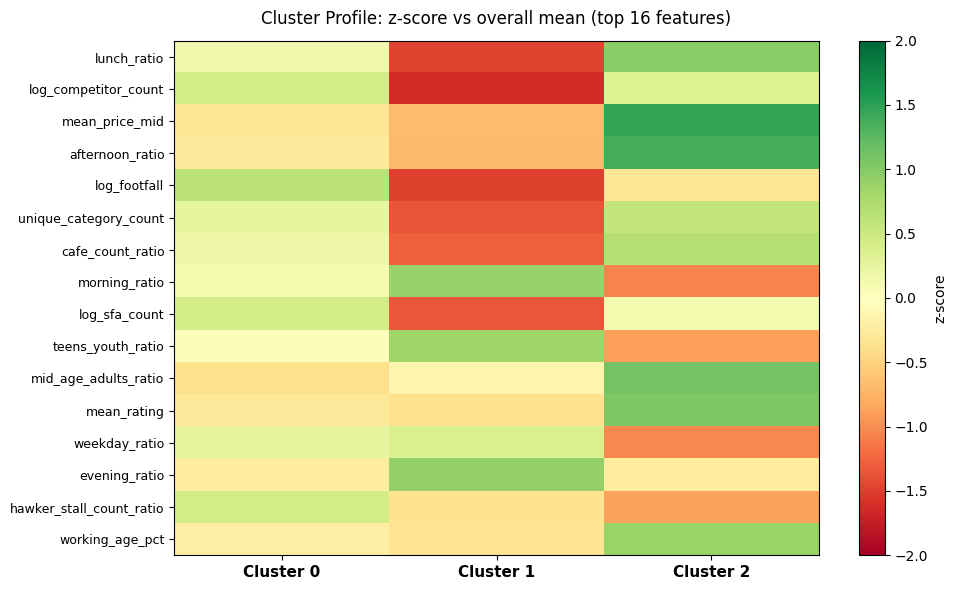

In [21]:
# Cluster profile heatmap: z-score of cluster mean vs overall mean
from matplotlib.colors import TwoSlopeNorm

overall_mean_v = X_imputed.mean()
overall_std_v  = X_imputed.std().replace(0, 1)
cluster_z = (kmeans_summary - overall_mean_v) / overall_std_v

# Pick the 16 features with the highest variance across clusters
top_features = cluster_z.var().sort_values(ascending=False).head(16).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
norm = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2)
im = ax.imshow(
    cluster_z[top_features].T.values,
    aspect='auto', cmap='RdYlGn', norm=norm
)

ax.set_xticks(range(final_k))
ax.set_xticklabels([f'Cluster {i}' for i in range(final_k)], fontsize=11, fontweight='bold')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features, fontsize=9)
ax.set_title('Cluster Profile: z-score vs overall mean (top 16 features)', fontsize=12, pad=12)

plt.colorbar(im, ax=ax, label='z-score')
plt.tight_layout()
plt.show()


The k=3 KMeans solution identifies three broad planning-area archetypes. These clusters should be interpreted as broad market archetypes rather than rankings. Each cluster may suit different F&B strategies depending on whether the target concept is mainstream, convenience-oriented, or premium-positioned.

Cluster 0 captures mainstream urban heartland hubs with high footfall, dense competition, and more affordable, hawker-heavy F&B environments.

Cluster 1 captures lower-intensity peripheral or special-use areas with sparse commercial ecosystems and weaker overall F&B density.

Cluster 2 captures premium central and lifestyle-oriented areas with higher prices, stronger ratings, greater category diversity, and a more upscale market profile.

# Pareto

In [22]:
pareto_base = analysis_df.copy()

pareto_base.head()

,PLANNING_AREA,total_footfall,total_inflow,weekday_volume,weekend_volume,afternoon,evening,lunch,morning,other,...,hawker_stall_count_ratio,restaurant_count_ratio,chinese_count_ratio,japanese_count_ratio,indian_count_ratio,cafe_count_ratio,thai_count_ratio,fast_food_count_ratio,market_quadrant_code,kmeans_cluster
0,ANG MO KIO,12643933,-55151,9188236,3455697,912723,3075086,2625614,2266392,3764118,...,0.273292,0.130435,0.080745,0.006211,0.018634,0.031056,0.018634,0.049689,1,0.0
1,BEDOK,17435585,100131,12241821,5193764,1406209,4168207,3620726,2940278,5300165,...,0.161369,0.207824,0.075795,0.012225,0.034230,0.026895,0.019560,0.019560,3,0.0
2,BISHAN,6582346,-200892,4724065,1858281,500037,1606145,1437977,1182105,1856082,...,0.162162,0.216216,0.070270,0.021622,0.005405,0.048649,0.043243,0.032432,3,0.0
3,BOON LAY,342658,34532,255329,87329,23326,93916,34464,91175,99777,...,0.125000,0.375000,0.000000,0.000000,0.125000,0.000000,0.000000,0.000000,0,1.0
4,BUKIT BATOK,9742955,-40587,6957018,2785937,754172,2407520,1975790,1648436,2957037,...,0.210526,0.204678,0.070175,0.017544,0.023392,0.011696,0.011696,0.046784,3,0.0


In [23]:
concepts = {
    "affordable_everyday_meal": {
        "key": "affordable_everyday_meal",
        "description": "Affordable everyday dining",
        "maximize": [
            "log_footfall",
            "log_sfa_count",
            "low_income_ratio",
            "mid_income_ratio",
            "hawker_stall_count_ratio",
        ],
        "minimize": [
            "mean_price_mid",
        ],
        "notes": "Best for mainstream, price-sensitive, repeat everyday demand. SFA count signals established hawker ecosystem."
    },

    "premium_cafe": {
        "key": "premium_cafe",
        "description": "Premium cafe / specialty cafe",
        "maximize": [
            "mean_price_mid",
            "high_income_ratio",
            "unique_category_count",
            "mean_rating",
        ],
        "minimize": [],
        "notes": "Best for upscale, lifestyle-oriented, higher-spending environments."
    },

    "worker_convenience": {
        "key": "worker_convenience",
        "description": "Office worker / lunch convenience",
        "maximize": [
            "log_footfall",
            "inflow_ratio",
            "weekday_ratio",
            "lunch_ratio",
            "working_age_pct",
        ],
        "minimize": [
            "mean_price_mid",
        ],
        "notes": "Best for office lunch demand, commuter inflows, and weekday peak traffic."
    },

    "family_casual_dining": {
        "key": "family_casual_dining",
        "description": "Family-oriented casual dining",
        "maximize": [
            "children_ratio",
            "mid_age_adults_ratio",
            "weekend_ratio",
            "mid_income_ratio",
        ],
        "minimize": [
            "mean_price_mid",
            "log_competitor_count",
        ],
        "notes": "Best for residential family demand and evening dining."
    },

    "youth_social_cafe": {
        "key": "youth_social_cafe",
        "description": "Youth-oriented social cafe",
        "maximize": [
            "young_adults_ratio",
            "teens_youth_ratio",
            "weekend_ratio",
            "unique_category_count",
            "mean_rating",
        ],
        "minimize": [],
        "notes": "Best for social dining, weekend hangouts, and younger demographics."
    },

    "local_cuisine": {
        "key": "local_cuisine",
        "description": "Local cuisine / traditional favorites",
        "maximize": [
            "chinese_count_ratio",
            "indian_count_ratio",
            "hawker_stall_count_ratio",
            "log_sfa_count",
        ],
        "minimize": [
            "cafe_count_ratio",
        ],
        "notes": "Best for local food environments with high SFA-licensed establishment density."
    },

    "fast_food_grab_go": {
        "key": "fast_food_grab_go",
        "description": "Fast-food / grab-and-go concept",
        "maximize": [
            "log_footfall",
            "weekday_ratio",
            "fast_food_count_ratio",
            "teens_youth_ratio",
        ],
        "minimize": [
            "mean_price_mid",
        ],
        "notes": "Best for high-throughput, convenience-oriented food demand."
    },
}


In [24]:
def pareto_efficient_mask(values: np.ndarray) -> np.ndarray:
    """
    Returns a boolean mask indicating which rows are Pareto-efficient.
    Assumes all columns are to be maximized.
    """
    n = values.shape[0]
    is_efficient = np.ones(n, dtype=bool)

    for i in range(n):
        if not is_efficient[i]:
            continue

        # A point j dominates i if:
        # j is >= i in all criteria and > i in at least one criterion
        dominates_i = np.all(values >= values[i], axis=1) & np.any(values > values[i], axis=1)

        # Exclude self-comparison
        dominates_i[i] = False

        if np.any(dominates_i):
            is_efficient[i] = False

    return is_efficient

def run_pareto(df: pd.DataFrame, concept_config: dict) -> pd.DataFrame:
    maximize_cols = concept_config["maximize"]
    minimize_cols = concept_config["minimize"]

    needed_cols = ["PLANNING_AREA"] + maximize_cols + minimize_cols
    if "kmeans_cluster" in df.columns:
        needed_cols.append("kmeans_cluster")

    concept_df = df[needed_cols].copy()

    # Drop rows with missing values in the required criteria
    concept_df = concept_df.dropna(subset=maximize_cols + minimize_cols).reset_index(drop=True)

    # Convert all criteria into "higher is better"
    for col in minimize_cols:
        concept_df[f"neg_{col}"] = -concept_df[col]

    pareto_cols = maximize_cols + [f"neg_{col}" for col in minimize_cols]

    values = concept_df[pareto_cols].to_numpy()
    mask = pareto_efficient_mask(values)

    concept_df["pareto_efficient"] = mask

    shortlist = concept_df[concept_df["pareto_efficient"]].copy()

    return shortlist, concept_df, pareto_cols

In [25]:
shortlist_hawker, full_hawker, hawker_pareto_cols = run_pareto(
    pareto_base,
    concepts["affordable_everyday_meal"]
)

In [26]:
shortlist_premium, full_premium, premium_pareto_cols = run_pareto(
    pareto_base,
    concepts["premium_cafe"]
)

In [27]:
shortlist_worker, full_worker, worker_pareto_cols = run_pareto(
    pareto_base,
    concepts["worker_convenience"]
)

In [28]:
shortlist_family, full_family, family_pareto_cols = run_pareto(
    pareto_base,
    concepts["family_casual_dining"]
)

In [29]:
shortlist_youth, full_youth, youth_pareto_cols = run_pareto(
    pareto_base,
    concepts["youth_social_cafe"]
)

In [30]:
shortlist_local_cuisine, full_local_cuisine, local_cuisine_pareto_cols = run_pareto(
    pareto_base,
    concepts["local_cuisine"]
)

In [31]:
shortlist_fast_food, full_fast_food, fast_food_pareto_cols = run_pareto(
    pareto_base,
    concepts["fast_food_grab_go"]
)

In [32]:
pareto_summary_list = []
pareto_all_shortlists = {}

for concept_key, concept_cfg in concepts.items():
    shortlist, full_df, pareto_cols = run_pareto(
        pareto_base,
        concept_cfg
    )

    pareto_all_shortlists[concept_key] = shortlist.copy()

    tmp = shortlist.copy()
    tmp["concept_key"] = concept_cfg["key"]
    tmp["concept_description"] = concept_cfg["description"]

    pareto_summary_list.append(tmp)

pareto_summary = pd.concat(pareto_summary_list, ignore_index=True)

concept_sort_cols = {
    "affordable_everyday_meal": "log_footfall",
    "premium_cafe": "mean_price_mid",
    "worker_convenience": "log_footfall",
    "family_casual_dining": "mid_income_ratio",
    "youth_social_cafe": "young_adults_ratio",
    "local_cuisine": "hawker_stall_count_ratio",
    "fast_food_grab_go": "log_footfall",
}

for concept_key, shortlist in pareto_all_shortlists.items():
    concept_cfg = concepts[concept_key]
    concept_title = concept_cfg["description"]

    print(f"\n===== {concept_title} =====")
    print(f"concept_key: {concept_key}")

    if shortlist.empty:
        print("No Pareto-efficient planning areas found.")
        continue

    sort_col = concept_sort_cols[concept_key]
    relevant_cols = concept_cfg["maximize"] + concept_cfg["minimize"]

    concept_table = (
        shortlist.sort_values(sort_col, ascending=False)
        .head(5)
        .copy()
    )

    concept_table["primary_value"] = concept_table[sort_col].round(3)
    concept_table["criteria_snapshot"] = concept_table[relevant_cols].round(3).astype(str).agg(
        lambda row: "; ".join(f"{col}={row[col]}" for col in relevant_cols),
        axis=1,
    )

    print(f"Primary metric: {sort_col}")
    print("Criteria used:", ", ".join(relevant_cols))

    display(concept_table[[
        "PLANNING_AREA",
        "primary_value",
        "criteria_snapshot",
    ]].reset_index(drop=True))


===== Affordable everyday dining =====
concept_key: affordable_everyday_meal
Primary metric: log_footfall
Criteria used: log_footfall, log_sfa_count, low_income_ratio, mid_income_ratio, hawker_stall_count_ratio, mean_price_mid


,PLANNING_AREA,primary_value,criteria_snapshot
0,WOODLANDS,16.877,log_footfall=16.877; log_sfa_count=7.017; low_...
1,TAMPINES,16.794,log_footfall=16.794; log_sfa_count=7.398; low_...
2,JURONG WEST,16.716,log_footfall=16.716; log_sfa_count=7.083; low_...
3,BEDOK,16.674,log_footfall=16.674; log_sfa_count=7.377; low_...
4,BUKIT MERAH,16.612,log_footfall=16.612; log_sfa_count=7.231; low_...



===== Premium cafe / specialty cafe =====
concept_key: premium_cafe
Primary metric: mean_price_mid
Criteria used: mean_price_mid, high_income_ratio, unique_category_count, mean_rating


,PLANNING_AREA,primary_value,criteria_snapshot
0,TANGLIN,50.667,mean_price_mid=50.667; high_income_ratio=0.81;...
1,RIVER VALLEY,48.559,mean_price_mid=48.559; high_income_ratio=0.776...
2,OUTRAM,42.372,mean_price_mid=42.372; high_income_ratio=0.387...
3,DOWNTOWN CORE,33.600,mean_price_mid=33.6; high_income_ratio=0.74; u...
4,BUKIT TIMAH,15.242,mean_price_mid=15.242; high_income_ratio=0.775...



===== Office worker / lunch convenience =====
concept_key: worker_convenience
Primary metric: log_footfall
Criteria used: log_footfall, inflow_ratio, weekday_ratio, lunch_ratio, working_age_pct, mean_price_mid


...

,PLANNING_AREA,primary_value,criteria_snapshot
0,DOWNTOWN CORE,0.177,young_adults_ratio=0.177; teens_youth_ratio=0....
1,MUSEUM,0.170,young_adults_ratio=0.17; teens_youth_ratio=0.0...
2,BUKIT BATOK,0.165,young_adults_ratio=0.165; teens_youth_ratio=0....
3,SEMBAWANG,0.164,young_adults_ratio=0.164; teens_youth_ratio=0....
4,CHOA CHU KANG,0.162,young_adults_ratio=0.162; teens_youth_ratio=0....



===== Local cuisine / traditional favorites =====
concept_key: local_cuisine
Primary metric: hawker_stall_count_ratio
Criteria used: chinese_count_ratio, indian_count_ratio, hawker_stall_count_ratio, log_sfa_count, cafe_count_ratio


,PLANNING_AREA,primary_value,criteria_snapshot
0,NEWTON,0.549,chinese_count_ratio=0.02; indian_count_ratio=0...
1,BUKIT MERAH,0.395,chinese_count_ratio=0.055; indian_count_ratio=...
2,WOODLANDS,0.388,chinese_count_ratio=0.029; indian_count_ratio=...
3,JURONG WEST,0.387,chinese_count_ratio=0.054; indian_count_ratio=...
4,KALLANG,0.334,chinese_count_ratio=0.082; indian_count_ratio=...



===== Fast-food / grab-and-go concept =====
concept_key: fast_food_grab_go
Primary metric: log_footfall
Criteria used: log_footfall, weekday_ratio, fast_food_count_ratio, teens_youth_ratio, mean_price_mid


,PLANNING_AREA,primary_value,criteria_snapshot
0,WOODLANDS,16.877,log_footfall=16.877; weekday_ratio=0.701; fast...
1,TAMPINES,16.794,log_footfall=16.794; weekday_ratio=0.72; fast_...
2,JURONG WEST,16.716,log_footfall=16.716; weekday_ratio=0.709; fast...
3,DOWNTOWN CORE,16.571,log_footfall=16.571; weekday_ratio=0.722; fast...
4,TOA PAYOH,16.393,log_footfall=16.393; weekday_ratio=0.719; fast...
